🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Pipeline (B)** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb) → [05 Suggest engine](../pipeline/05_suggest_engine.ipynb) · [07 Run week + report](../pipeline/07_run_week_and_report.ipynb)
**Tutorials (A)** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics (C)** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb)
**Neural + LLM (D)** · [08 NN (educational)](../neural/08_neural_surrogates_edu.ipynb) · [09 NN for F6](../neural/09_neural_surrogates_F6.ipynb) · [10 NN engine](../neural/10_neural_surrogates_engine.ipynb)

> 📍 **This notebook** — **Auxiliary diagnostic (C · never selects a query). Logistic-regression top-vs-rest separability cross-check.**

---

# You Sank My Function! — Logistic Regression Analysis
## Imperial College Business School — Capstone Project

> **Purpose:** Apply logistic regression as a *complement* to the GP surrogate model.
> Where GPs model the full landscape, logistic regression asks a simpler question:
> *which input dimensions predict whether a point is in the top 30% of outputs?*
> The coefficients — once properly scaled — give directional guidance with a fraction of the compute.

**Functions analysed:**
| Function | Dims | Hypothesis | LR Role | Status |
|----------|------|------------|---------|--------|
| F2 | 2D | Six-hump camelback | Directional | Inconclusive — boundary saturation, overruled |
| F4 | 4D | Shekel / smooth basin | Directional | x1↓ x3↓ confirmed |
| F6 | 5D | Styblinski-Tang (rejected) | Directional | Centrepiece — x5 coef evolution −1.568→−0.634 |
| F5 | 4D | Hartmann 4D scaled | Directional | Mixed signal — x4↑ x1/x2/x3↓ |
| F8 | 8D | Ackley negated/shifted | Directional | x4 asymmetry confirmed, 80th pct threshold |
| F3 | 3D | Hartmann 3D (confirmed ✓) | **Validation** | Control case — known optimum at (0.114, 0.556, 0.852) |
| F7 | 6D | Hartmann 6D negated (confirmed ✓) | **Validation** | Control case — richest test, 6 known directions |

**Why not F1?** Branin-Hoo (2D, 3 optima) guarantees the same boundary saturation as F2.
A linear plane cannot separate three clusters; GP exploration is strictly more informative.

**Control case logic:** F3 and F7 are the only functions where ground truth is known.
If LR coefficients point toward the true optima, that validates the method for uncertain functions.
If they fail, that quantifies the method's limitations honestly.

---
**How to use this notebook each week:**
1. Uncomment the next query row in **Cell 3** (F2/F4/F6) or the relevant function cell
2. Re-run all cells — thresholds, models, and plots update automatically
3. Read the coefficient tables to see if any direction has reversed
4. Check F3/F7 validation scores — if they drop, treat all LR signals with more caution

---
## Section 1 — Theory: Why Logistic Regression?

### 1.1 The core idea: binarising a continuous problem

We are maximising a continuous function $f(\mathbf{x})$ over $[0,1]^d$.
We have a small number of observations $(\mathbf{x}_i, y_i)$.
Logistic regression cannot predict $y$ directly — it is a *classifier*, not a regressor.
So we ask a different question:

> *Which inputs $\mathbf{x}$ tend to produce outputs in the **top 30%** of what we have seen so far?*

We convert each $y_i$ to a binary label:
$$
z_i = \begin{cases} 1 & \text{if } y_i > \tau \\  0 & \text{otherwise} \end{cases}
$$
where $\tau$ is the **70th percentile** of all observed outputs.
This gives roughly a 70/30 class split — enough Class 1 points to fit a stable model,
while still labelling only the genuinely good observations as promising.

**Why 70th percentile?** Two competing constraints:
- Too high (e.g. 95th percentile) → only 1–2 positive examples; model is unstable
- Too low (e.g. 50th percentile) → half the points are 'promising'; signal is diluted

70% is a pragmatic balance for the small datasets in this challenge (10–30 initial points).

---
### 1.2 Why StandardScaler is **mandatory**

Logistic regression optimises:
$$
P(z=1 \mid \mathbf{x}) = \sigma\!\left(\beta_0 + \sum_{j=1}^d \beta_j x_j\right)
$$
where $\sigma$ is the sigmoid function.

**The problem:** If $x_1 \in [0, 1]$ and $x_2 \in [0, 1000]$, a coefficient $\beta_1 = 2.0$
means a 1-unit change in $x_1$ — but a 1-unit change in $x_2$ is only a 0.1% shift in its range.
The coefficients are **not comparable** on different scales.

All our inputs are already in $[0,1]$, so this is less critical here — but StandardScaler
also centres each dimension at zero, which:
- Improves convergence of the L-BFGS solver
- Makes the intercept $\beta_0$ interpretable as the log-odds at the *mean* input
- Ensures coefficients are comparable across dimensions (same unit: one standard deviation)

**Rule:** Always fit the scaler on training data (`scaler.fit_transform(X_train)`) and apply
the *same* scaler to any new points (`scaler.transform(X_new)`). Never re-fit on new data.

---
### 1.3 What logistic regression *cannot* do — the linear boundary limitation

Logistic regression draws a single **hyperplane** in input space as its decision boundary:
$$
\{\mathbf{x} : \beta_0 + \boldsymbol{\beta}^\top \mathbf{x} = 0\}
$$
This is a fundamental limitation when the true promising region is:
- **Multi-modal** — e.g. Branin-Hoo has two optima; a single hyperplane cannot enclose both
- **Non-convex** — e.g. the six-hump camelback (F2) has a curved ridge of good values
- **Centred** — Styblinski-Tang has its optimum near 0.21 in normalised space; the plane
  may point toward the boundary rather than the interior

The GP surrogate has none of these limitations — it models the full response surface.
**Logistic regression is used here as a cheap directional check, not as a replacement for GP.**

| Property | Logistic Regression | GP Surrogate |
|----------|--------------------|--------------|
| Decision boundary | Linear hyperplane | Arbitrary shape |
| Outputs | P(class=1) ∈ [0,1] | μ(x) + σ(x) |
| Data needed | ~10+ points | Works from 1 point |
| Interpretability | Coefficients = directions | Less direct |
| Compute cost | Milliseconds | Seconds (kernel inversion) |
| Multi-modal support | ✗ | ✓ |

## Cell 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

print('Imports OK.')

Imports OK.


## Cell 2 — Load all data from `consolidated_observations.csv`

Every observation for all eight functions now lives in a single tidy file,
`consolidated_observations.csv` (one row per evaluation). The `source` column
splits the original space-filling design (`initial`) from the live
Bayesian-optimisation points (`weekly`), and the `week` column orders them.

Just keep `consolidated_observations.csv` in the same folder as this notebook —
no `.npy` files and no per-week editing required.

In [2]:
import os
import numpy as np
import pandas as pd

# ── Single data source: consolidated_observations.csv (initial + all weeks) ──
# Override the location with the BBO_DATA_FILE environment variable if needed;
# otherwise it is read from the folder this notebook runs in.
DATA_FILE = os.environ.get("BBO_DATA_FILE", "consolidated_observations.csv")
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"Could not find {DATA_FILE!r} in {os.getcwd()!r}. "
        "Put consolidated_observations.csv next to this notebook, "
        "or set the BBO_DATA_FILE environment variable."
    )
OBS = pd.read_csv(DATA_FILE)


def load_function(fid):
    """Return (X_init, y_init, X_weekly, y_weekly, X_full, y_full) for a function.

    Pulls every observation from the consolidated table. The 'source' column
    splits the initial design ('initial') from the live weekly points
    ('weekly'); rows are ordered by 'week' so the weekly points append in
    chronological order. Only the function's active x1..x{dim} columns are kept.
    """
    if isinstance(fid, str):                       # accept 'function_5', 'f5', '5'
        fid = int("".join(ch for ch in fid if ch.isdigit()))
    sub = OBS[OBS["function"] == fid].sort_values("week").reset_index(drop=True)
    if sub.empty:
        raise ValueError(f"No rows for function {fid} in {DATA_FILE}.")
    dim = int(sub["dim"].iloc[0])
    xcols = [f"x{i}" for i in range(1, dim + 1)]

    def XY(frame):
        return frame[xcols].to_numpy(float), frame["y"].to_numpy(float)

    Xi, yi = XY(sub[sub["source"] == "initial"])
    Xw, yw = XY(sub[sub["source"] == "weekly"])
    Xf, yf = XY(sub)
    return Xi, yi, Xw, yw, Xf, yf


# Materialise the per-function arrays the analysis cells expect (F2..F8).
# F{n}_X_init / _y_init : initial design only
# F{n}_X_queries / _y_queries : weekly Bayesian-optimisation points (all weeks)
# F{n}_X / _y : the two combined
for _fid in range(1, 9):
    Xi, yi, Xw, yw, Xf, yf = load_function(_fid)
    globals()[f"F{_fid}_X_init"]    = Xi
    globals()[f"F{_fid}_y_init"]    = yi
    globals()[f"F{_fid}_X_queries"] = Xw
    globals()[f"F{_fid}_y_queries"] = yw
    globals()[f"F{_fid}_X"]         = Xf
    globals()[f"F{_fid}_y"]         = yf

print(f"Loaded {len(OBS)} observations from {DATA_FILE} "
      f"(weeks {OBS['week'].min()}-{OBS['week'].max()}).")

Loaded 279 observations from consolidated_observations.csv (weeks 0-13).


## Cell 3 — Combined dataset sizes

The weekly results are already embedded in `consolidated_observations.csv`, so
there is nothing to paste in each week — re-exporting the consolidated file is
enough. The cell below just confirms how many observations each function now
carries (initial design + weekly points).

In [3]:
print("Combined dataset sizes (initial + weekly, from the consolidated file):")
for fid in range(2, 9):
    Xf = globals()[f"F{fid}_X"]
    Xi = globals()[f"F{fid}_X_init"]
    Xw = globals()[f"F{fid}_X_queries"]
    yf = globals()[f"F{fid}_y"]
    print(f"  F{fid}: {Xf.shape[0]:>3} obs ({Xi.shape[0]} initial + {Xw.shape[0]} weekly), "
          f"dim={Xf.shape[1]}, y in [{yf.min():.4f}, {yf.max():.4f}]")

Combined dataset sizes (initial + weekly, from the consolidated file):
  F2:  23 obs (10 initial + 13 weekly), dim=2, y in [-0.1261, 0.6505]
  F3:  28 obs (15 initial + 13 weekly), dim=3, y in [-0.4432, -0.0004]
  F4:  43 obs (30 initial + 13 weekly), dim=4, y in [-32.6257, 0.6549]
  F5:  33 obs (20 initial + 13 weekly), dim=4, y in [0.1129, 8662.4825]
  F6:  33 obs (20 initial + 13 weekly), dim=5, y in [-2.5712, -0.2347]
  F7:  43 obs (30 initial + 13 weekly), dim=6, y in [0.0027, 3.3224]
  F8:  53 obs (40 initial + 13 weekly), dim=8, y in [5.5922, 10.0000]


## Cell 4 — Utility functions

Three functions do all the work:

| Function | What it does |
|----------|--------------|
| `apply_threshold(y, τ)` | Converts continuous outputs to binary labels (1 = above τ) |
| `fit_logistic(X, z)` | Scales X, fits `LogisticRegression`, returns sorted coefficient table |
| `find_best_query(clf, scaler, dims, ...)` | Grid-searches $[0,1]^d$ for the point with highest P(class=1) |

In [4]:
def apply_threshold(y, threshold, label=''):
    """
    Convert continuous outputs y to binary class labels.

    Class 1 = 'promising' = y > threshold (typically the 70th percentile).
    Class 0 = 'not promising' = y <= threshold.

    Parameters
    ----------
    y         : 1D array of function outputs
    threshold : float — typically np.percentile(y, 70)
    label     : str   — printed in diagnostic output

    Returns
    -------
    binary : 1D int array of 0/1 labels
    """
    binary = (y > threshold).astype(int)
    n_pos  = binary.sum()
    n_neg  = len(binary) - n_pos
    print(f'\n  {label} threshold = {threshold:.4f}')
    print(f'  Class 1 (above): {n_pos} | Class 0 (below): {n_neg}')
    if n_pos < 2 or n_neg < 2:
        print(f'  ⚠ WARNING: Very imbalanced split — consider adjusting threshold')
    return binary


def fit_logistic(X, y_binary, feature_names=None):
    """
    Fit logistic regression with StandardScaler preprocessing.

    Steps:
      1. StandardScaler: zero-mean, unit-variance per dimension
         → coefficients become comparable across dimensions
      2. LogisticRegression with L2 regularisation (C=1.0)
         → prevents overfitting on small datasets
      3. Returns coefficient table sorted by |coefficient| descending
         → most influential dimension listed first

    Parameters
    ----------
    X             : (n, d) array of inputs in [0,1]^d
    y_binary      : (n,) int array of 0/1 labels
    feature_names : list of strings, default ['x1', 'x2', ...]

    Returns
    -------
    clf      : fitted LogisticRegression
    scaler   : fitted StandardScaler (keep this — apply to new points)
    coef_df  : DataFrame with Feature, Coefficient, Abs_Coef, Direction
    """
    if len(np.unique(y_binary)) < 2:
        print('  ✗ Cannot fit: only one class present')
        return None, None, None

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42, solver='lbfgs')
    clf.fit(X_scaled, y_binary)

    if feature_names is None:
        feature_names = [f'x{i+1}' for i in range(X.shape[1])]

    coef_df = pd.DataFrame({
        'Feature':     feature_names,
        'Coefficient': clf.coef_[0],
        'Abs_Coef':    np.abs(clf.coef_[0]),
        'Direction':   ['↑ higher x = more promising' if c > 0
                        else '↓ lower x = more promising'
                        for c in clf.coef_[0]]
    }).sort_values('Abs_Coef', ascending=False)

    y_pred = clf.predict(X_scaled)
    acc    = (y_pred == y_binary).mean()
    print(f'  Training accuracy: {acc:.1%}')
    return clf, scaler, coef_df


def find_best_query(clf, scaler, dims, fixed_dims=None, fixed_vals=None, n=80):
    """
    Grid-search [0,1]^dims for the point maximising P(class=1).

    The grid varies dimensions 0 and 1 (an n×n mesh); all other dimensions
    are held fixed at fixed_vals.  This produces a 2D probability map
    suitable for visualisation regardless of the true dimensionality.

    Parameters
    ----------
    clf        : fitted LogisticRegression
    scaler     : fitted StandardScaler — must be the same one used in fit_logistic
    dims       : int — total number of input dimensions
    fixed_dims : list of int — dimension indices to hold fixed
    fixed_vals : list of float — values to fix those dimensions at
    n          : int — grid resolution per axis (default 80 → 6400 points)

    Returns
    -------
    X1_grid  : (n,n) meshgrid for axis 0 (for contourf)
    X2_grid  : (n,n) meshgrid for axis 1 (for contourf)
    proba_map: (n,n) probability map P(class=1)
    best_x   : (dims,) point with highest P(class=1) on the grid
    best_prob: float — probability at best_x
    """
    x    = np.linspace(0, 1, n)
    X1g, X2g = np.meshgrid(x, x)
    X_grid   = np.zeros((n * n, dims))
    X_grid[:, 0] = X1g.ravel()
    X_grid[:, 1] = X2g.ravel()
    if fixed_dims and fixed_vals:
        for d, v in zip(fixed_dims, fixed_vals):
            X_grid[:, d] = v
    proba    = clf.predict_proba(scaler.transform(X_grid))[:, 1]
    best_idx = np.argmax(proba)
    return X1g, X2g, proba.reshape(n, n), X_grid[best_idx], proba[best_idx]


print('Utility functions defined.')

Utility functions defined.


---
## Section 2 — F2 (2D): Inconclusive — Boundary Saturation

**Hypothesis:** F2 is the six-hump camelback — two global optima near $(0.09, 0.71)$
and $(0.91, 0.29)$ in normalised $[0,1]^2$ space.

**What logistic regression found:**
Both x1 and x2 have *positive* coefficients, pointing toward $(1.0, 1.0)$.
The recommended query is the boundary corner — the model has not seen enough
of the space to distinguish the two optima from a general 'high x is better' trend.

**Why this is inconclusive — honest science:**

With only 11 observations in 2D, the 70th percentile threshold creates just 3 positive
class examples. Three points in 2D can always be separated by a hyperplane that may
or may not reflect the true structure. When two of those three points happen to have
relatively high x1 *and* x2, the classifier extrapolates to the corner.

The camelback function has a valley at $(0.5, 0.5)$ — the classifier's boundary does
not capture this. **This is the linear boundary limitation in action.**

**Decision:** Do not follow the logistic regression suggestion of $(1.0, 1.0)$.
Use the GP surrogate to explore the third potential optimum in Week 2.

### Cell 5 — F2 logistic regression (2D)

In [5]:
print('=' * 60)
print('  F2 — LOGISTIC REGRESSION (2D)')
print('=' * 60)
print(f'  y range: {F2_y.min():.4f} to {F2_y.max():.4f}')

# 70th percentile threshold: keeps top ~30% as Class 1
# With 11 points this gives 3 positive examples — borderline for stability
F2_threshold = np.percentile(F2_y, 70)
print(f'  Auto threshold (70th percentile): {F2_threshold:.4f}')

F2_binary = apply_threshold(F2_y, F2_threshold, 'F2')
clf_f2, scaler_f2, coef_f2 = fit_logistic(F2_X, F2_binary, ['x1', 'x2'])

if clf_f2:
    print('\n  Feature importances (sorted by |coefficient|):')
    print(coef_f2.to_string(index=False))
    print('\n  ⚠ CAUTION: Only 3 positive examples — boundary saturation likely')
    print('  Positive coeff on both x1 and x2 → model pointing at corner (1,1)')
    print('  This contradicts the camelback structure — GP takes precedence')

    X1_f2, X2_f2, proba_f2, best_x_f2, best_p_f2 = find_best_query(
        clf_f2, scaler_f2, dims=2
    )
    print(f'\n  Logistic regression suggested query: ({best_x_f2[0]:.6f}, {best_x_f2[1]:.6f})')
    print(f'  P(above threshold) = {best_p_f2:.4f}')
    print(f'  Portal format: {best_x_f2[0]:.6f}-{best_x_f2[1]:.6f}')
    print(f'\n  ↳ Decision: OVERRULED — GP exploration of third optimum preferred')

  F2 — LOGISTIC REGRESSION (2D)
  y range: -0.1261 to 0.6505
  Auto threshold (70th percentile): 0.5686

  F2 threshold = 0.5686
  Class 1 (above): 7 | Class 0 (below): 16
  Training accuracy: 65.2%

  Feature importances (sorted by |coefficient|):
Feature  Coefficient  Abs_Coef                   Direction
     x1     0.618454  0.618454 ↑ higher x = more promising
     x2    -0.214006  0.214006  ↓ lower x = more promising

  ⚠ CAUTION: Only 3 positive examples — boundary saturation likely
  Positive coeff on both x1 and x2 → model pointing at corner (1,1)
  This contradicts the camelback structure — GP takes precedence

  Logistic regression suggested query: (1.000000, 0.000000)
  P(above threshold) = 0.6372
  Portal format: 1.000000-0.000000

  ↳ Decision: OVERRULED — GP exploration of third optimum preferred


---
## Section 3 — F4 (4D): Directional Signal — Negative x1 and x3

**Hypothesis:** F4 is a Shekel function or smooth basin — the optimum is somewhere
in the interior of $[0,1]^4$, likely near a concentrated peak.

**What logistic regression found:**

| Feature | Coefficient | Interpretation |
|---------|-------------|----------------|
| x1 | −0.751 | Lower x1 → more promising |
| x3 | −0.546 | Lower x3 → more promising |
| x2 | small | Weak signal |
| x4 | small | Weak signal |

The best Week 1 query $(0.5, 0.5, 0.5, 0.5)$ returned $-3.986$, which is already
the best observed value. The logistic regression confirms that moving toward lower
x1 and x3 is the right direction for Week 2.

**Limitation:** x2 and x4 coefficients are small and unstable with 31 points.
The model is held fixed for those dimensions at the best known observation.
The Week 2 suggestion varies only x1 and x3 as directed.

### Cell 6 — F4 logistic regression (4D)

In [6]:
print('=' * 60)
print('  F4 — LOGISTIC REGRESSION (4D)')
print('=' * 60)
print(f'  y range: {F4_y.min():.4f} to {F4_y.max():.4f}')
print('  Note: F4 outputs are negative — higher (less negative) = better')

# Threshold: top 30% of observed values
# With 31 points this gives ~9 positive examples — stable
F4_threshold = np.percentile(F4_y, 70)
print(f'  Auto threshold (70th percentile): {F4_threshold:.4f}')

F4_binary = apply_threshold(F4_y, F4_threshold, 'F4')
clf_f4, scaler_f4, coef_f4 = fit_logistic(F4_X, F4_binary, ['x1','x2','x3','x4'])

if clf_f4:
    print('\n  Feature importances (sorted by |coefficient|):')
    print(coef_f4.to_string(index=False))

    # Fix x3/x4 at the best known observation, vary x1/x2
    best_known_f4 = F4_X[np.argmax(F4_y)]
    print(f'\n  Best known point: {np.round(best_known_f4, 4).tolist()}')
    print(f'  Fixing x3={best_known_f4[2]:.4f}, x4={best_known_f4[3]:.4f}')
    print(f'  Varying x1/x2 to find highest P(class=1)')

    X1_f4, X2_f4, proba_f4, best_x_f4_2d, best_p_f4 = find_best_query(
        clf_f4, scaler_f4, dims=4,
        fixed_dims=[2, 3],
        fixed_vals=[best_known_f4[2], best_known_f4[3]]
    )
    best_x_f4 = best_known_f4.copy()
    best_x_f4[0] = best_x_f4_2d[0]
    best_x_f4[1] = best_x_f4_2d[1]

    print(f'\n  Recommended next query (x1/x2 varied, x3/x4 fixed at best known):')
    print(f'  x = {np.round(best_x_f4, 6).tolist()}')
    print(f'  P(above threshold) = {best_p_f4:.4f}')
    print(f'  Portal format: {"-".join([f"{v:.6f}" for v in best_x_f4])}')

  F4 — LOGISTIC REGRESSION (4D)
  y range: -32.6257 to 0.6549
  Note: F4 outputs are negative — higher (less negative) = better
  Auto threshold (70th percentile): -5.6315

  F4 threshold = -5.6315
  Class 1 (above): 13 | Class 0 (below): 30
  Training accuracy: 67.4%

  Feature importances (sorted by |coefficient|):
Feature  Coefficient  Abs_Coef                  Direction
     x3    -0.372953  0.372953 ↓ lower x = more promising
     x4    -0.315060  0.315060 ↓ lower x = more promising
     x2    -0.175516  0.175516 ↓ lower x = more promising
     x1    -0.131869  0.131869 ↓ lower x = more promising

  Best known point: [0.427, 0.4112, 0.3533, 0.4101]
  Fixing x3=0.3533, x4=0.4101
  Varying x1/x2 to find highest P(class=1)

  Recommended next query (x1/x2 varied, x3/x4 fixed at best known):
  x = [0.0, 0.0, 0.3533, 0.4101]
  P(above threshold) = 0.4654
  Portal format: 0.000000-0.000000-0.353300-0.410100


---
## Section 4 — F6 (5D): The Centrepiece — Coefficient Evolution

F6 is the most instructive function in this notebook. It was initially hypothesised
to be a rescaled Styblinski-Tang function — which has its optimum at approximately
$x_i = 0.2097$ in normalised space for each dimension. That hypothesis was **rejected**
because the function's landscape does not match the Styblinski-Tang signature.

The logistic regression provides the clearest directional signal in the dataset:
**x5 should be driven toward zero, and x4 should be high.**

### 4.1 The centrepiece story: coefficient evolution of x5

The x5 coefficient shifted materially between the initial data and after Week 1:

| Data snapshot | x5 coefficient | x4 coefficient | Top-ranked feature |
|---------------|---------------|---------------|--------------------|
| Initial data only (20 obs) | **−1.568** | +1.123 | x5 (strong negative) |
| After Week 1 (21 obs) | **−0.634** | +0.727 | x4 (now dominant) |

**What this tells us:**

1. **Direction is consistent** — x5 negative in both snapshots. The signal is real.
2. **Magnitude halved** after adding one data point. This is expected when the
   initial 20 points happen to cluster in a region where x5 correlates strongly
   with output. One point in a different region dilutes the apparent importance.
3. **x4 became dominant** after Week 1 — the new data point $(0.2097, ..., 0.2097)$
   with its middling return pushed x4's positive coefficient to the front rank.
4. **Implication for queries:** Even after dilution, x5 negative means push toward
   $x5 \approx 0$. The Week 2 suggested query has $x5 = 0.020$ from the GP.

### 4.2 Why the hypothesis was rejected

The Styblinski-Tang optimum in normalised space is $(0.2097, 0.2097, 0.2097, 0.2097, 0.2097)$.
The Week 1 query submitted there returned $-1.507$, while the initial best was $-0.714$.
A true Styblinski-Tang would return its global maximum at that point — it did not.
The function has different structure, and the logistic regression coefficients
(unequal across dimensions) confirm it is not isotropic.

### Cell 7 — F6 logistic regression (5D)

In [7]:
print('=' * 60)
print('  F6 — LOGISTIC REGRESSION (5D) — CENTREPIECE')
print('=' * 60)
print(f'  y range: {F6_y.min():.4f} to {F6_y.max():.4f}')
print('  Note: F6 hypothesis (Styblinski-Tang) REJECTED')
print('  Strategy: exploit x5→0 and x4→1 signals from logistic regression')

# ── Coefficient evolution: compute on initial data alone ─────────────────
print('\n  --- COEFFICIENT EVOLUTION ---')
print('  Fitting on INITIAL DATA ONLY (20 obs):')
F6_threshold_init = np.percentile(F6_y_init, 70)
F6_binary_init    = apply_threshold(F6_y_init, F6_threshold_init, 'F6-init')
clf_f6_init, scaler_f6_init, coef_f6_init = fit_logistic(
    F6_X_init, F6_binary_init, ['x1','x2','x3','x4','x5'])

if coef_f6_init is not None:
    print('  Coefficients (initial data only):')
    print(coef_f6_init[['Feature','Coefficient']].to_string(index=False))

print('\n  Fitting on FULL DATA (initial + all weekly points):')
F6_threshold = np.percentile(F6_y, 70)
F6_binary    = apply_threshold(F6_y, F6_threshold, 'F6-full')
clf_f6, scaler_f6, coef_f6 = fit_logistic(
    F6_X, F6_binary, ['x1','x2','x3','x4','x5'])

if coef_f6 is not None:
    print('  Coefficients (full data):')
    print(coef_f6[['Feature','Coefficient']].to_string(index=False))

# ── Coefficient evolution table ───────────────────────────────────────────
if coef_f6_init is not None and coef_f6 is not None:
    print('\n  ┌─────────────────────────────────────────────────────────┐')
    print('  │  F6 COEFFICIENT EVOLUTION — x5 centrepiece story        │')
    print('  ├──────────┬────────────────────┬──────────────────────────┤')
    print('  │ Feature  │ Initial (20 obs)   │ Full (initial+weeks)   │')
    print('  ├──────────┼────────────────────┼──────────────────────────┤')
    for feat in ['x1','x2','x3','x4','x5']:
        c_init = coef_f6_init[coef_f6_init['Feature']==feat]['Coefficient'].values
        c_full = coef_f6[coef_f6['Feature']==feat]['Coefficient'].values
        ci = f'{c_init[0]:+.3f}' if len(c_init) else 'N/A'
        cf = f'{c_full[0]:+.3f}' if len(c_full) else 'N/A'
        marker = '  ← centrepiece' if feat == 'x5' else ''
        print(f'  │ {feat:8s} │ {ci:18s} │ {cf:24s}│{marker}')
    print('  └──────────┴────────────────────┴──────────────────────────┘')
    print()
    print('  Interpretation:')
    print('  • x5 negative in both snapshots → consistent direction (push x5 → 0)')
    print('  • x5 stays strongly negative on the full data → the push-x5→0 signal holds up')
    print('  • x4 now dominant → high x4 strongly predicts promising region')
    print('  • Signal is real; W2 query uses x5=0.020, x4=0.850 per GP+LR consensus')

if clf_f6:
    # Vary x4/x5 (dominant dims), fix x1/x2/x3 at best known
    best_known_f6 = F6_X[np.argmax(F6_y)]
    X1_f6, X2_f6, proba_f6, best_x_f6_2d, best_p_f6 = find_best_query(
        clf_f6, scaler_f6, dims=5,
        fixed_dims=[0, 1, 2],
        fixed_vals=[best_known_f6[0], best_known_f6[1], best_known_f6[2]]
    )
    best_x_f6 = best_known_f6.copy()
    best_x_f6[3] = best_x_f6_2d[0]   # x4 → dimension 0 of grid
    best_x_f6[4] = best_x_f6_2d[1]   # x5 → dimension 1 of grid

    print(f'\n  Recommended next query (x4/x5 varied, x1/x2/x3 fixed):')
    print(f'  x = {np.round(best_x_f6, 6).tolist()}')
    print(f'  P(above threshold) = {best_p_f6:.4f}')
    print(f'  Portal format: {"-".join([f"{v:.6f}" for v in best_x_f6])}')

  F6 — LOGISTIC REGRESSION (5D) — CENTREPIECE
  y range: -2.5712 to -0.2347
  Note: F6 hypothesis (Styblinski-Tang) REJECTED
  Strategy: exploit x5→0 and x4→1 signals from logistic regression

  --- COEFFICIENT EVOLUTION ---
  Fitting on INITIAL DATA ONLY (20 obs):

  F6-init threshold = -1.2431
  Class 1 (above): 6 | Class 0 (below): 14
  Training accuracy: 80.0%
  Coefficients (initial data only):
Feature  Coefficient
     x5    -0.732001
     x4     0.627891
     x1    -0.577794
     x2    -0.293276
     x3     0.163028

  Fitting on FULL DATA (initial + all weekly points):

  F6-full threshold = -0.4289
  Class 1 (above): 10 | Class 0 (below): 23
  Training accuracy: 93.9%
  Coefficients (full data):
Feature  Coefficient
     x5    -1.643333
     x1    -0.966645
     x3     0.613937
     x2    -0.564054
     x4     0.439531

  ┌─────────────────────────────────────────────────────────┐
  │  F6 COEFFICIENT EVOLUTION — x5 centrepiece story        │
  ├──────────┬────────────────────┬

---
## Section 6 — F5 (4D, Scaled): Directional Validation — Which Dimension Dominates?

**Hypothesis:** F5 is a scaled Hartmann 4D function. The Hartmann 4D true global optimum
sits at approximately $(0.20, 0.175, 0.477, 0.275)$ in the unit hypercube — an **interior**
point, well away from any boundary.

**What the GP found so far:**
- Initial best observation: 1088.9 — the GP's acquisition function found a region of high output
- Week 1 query near the high corner returned 94.67 — a dramatic drop
- The regression confirmed a 'high corner' direction from the initial data

**Why logistic regression adds value here:**
With 4 dimensions and ~30 observations, the GP tells us *where* it is uncertain but does not
naturally produce a ranked list of which dimensions drive the output. Logistic regression
answers: **of x1, x2, x3, x4 — which one or two carry the most information about whether
a point is in the top 30%?** That ranking can focus remaining queries.

**⚠ Critical caveat — the wrong-direction risk:**

The Hartmann 4D true optimum is interior, but if the initial 30 observations happen to cluster
near the scaled function's rescaled peak, LR might confidently point in a direction that
reflects the *current data distribution* rather than the global structure.
The W1 result of 94.67 (vs initial best 1088.9) is already a warning sign: moving toward
the high corner was the *wrong* direction.

**Rule:** If LR reinforces the high-corner direction, treat it with suspicion — that direction
has already been tested and returned a worse result. If LR points *away* from the corner,
that is a stronger signal worth following.

### Cell 10 — F5 logistic regression (4D, scaled Hartmann)

In [8]:
# F5 data (initial design + all weekly points) is already loaded from
# consolidated_observations.csv in Cell 2.
print('=' * 60)
print('  F5 — LOGISTIC REGRESSION (4D, SCALED HARTMANN)')
print('=' * 60)
print(f'  y range: {F5_y.min():.4f} to {F5_y.max():.4f}')
print(f'  Observations: {F5_X.shape[0]} ({F5_X_init.shape[0]} initial + {F5_X_queries.shape[0]} weekly)')
print(f'  WARNING: W1 result {F5_y_queries[0]:.2f} << initial best {F5_y_init.max():.2f}')
print(f'           High-corner direction likely wrong — watch coefficient signs carefully')

# Standard 70th percentile threshold
F5_threshold = np.percentile(F5_y, 70)
print(f'\n  Auto threshold (70th percentile): {F5_threshold:.4f}')

F5_binary = apply_threshold(F5_y, F5_threshold, 'F5')
clf_f5, scaler_f5, coef_f5 = fit_logistic(F5_X, F5_binary, ['x1','x2','x3','x4'])

if clf_f5:
    print('\n  Feature importances (sorted by |coefficient|):')
    print(coef_f5.to_string(index=False))

    best_known_f5 = F5_X[np.argmax(F5_y)]
    print(f'\n  Best known point: {np.round(best_known_f5, 4).tolist()}')

    # Vary top-2 most important dims, fix the other two at best known
    feat_order = ['x1','x2','x3','x4']
    top2_pos   = [feat_order.index(coef_f5.iloc[0]['Feature']),
                  feat_order.index(coef_f5.iloc[1]['Feature'])]
    fix_pos    = [p for p in range(4) if p not in top2_pos]
    fix_vals   = [best_known_f5[p] for p in fix_pos]

    n = 80
    x = np.linspace(0, 1, n)
    X1g, X2g = np.meshgrid(x, x)
    X_grid_f5 = np.zeros((n*n, 4))
    X_grid_f5[:, top2_pos[0]] = X1g.ravel()
    X_grid_f5[:, top2_pos[1]] = X2g.ravel()
    for p, v in zip(fix_pos, fix_vals):
        X_grid_f5[:, p] = v
    proba_f5_flat = clf_f5.predict_proba(scaler_f5.transform(X_grid_f5))[:, 1]
    best_idx_f5   = np.argmax(proba_f5_flat)
    X1_f5 = X1g
    X2_f5 = X2g
    proba_f5  = proba_f5_flat.reshape(n, n)
    best_x_f5 = X_grid_f5[best_idx_f5]
    best_p_f5 = proba_f5_flat[best_idx_f5]

    print(f'\n  Grid varies: {feat_order[top2_pos[0]]} (axis 0) '
          f'and {feat_order[top2_pos[1]]} (axis 1)')
    print(f'  Fixed dims:  '
          f'{ {feat_order[p]: round(v,4) for p, v in zip(fix_pos, fix_vals)} }')
    print(f'\n  Recommended next query:')
    print(f'  x = {np.round(best_x_f5, 6).tolist()}')
    print(f'  P(above threshold) = {best_p_f5:.4f}')
    print(f'  Portal format: {"-".join([f"{v:.6f}" for v in best_x_f5])}')

    # ── Interpretation check — reads full coefficient pattern, not just top feature ──
    coef_dict   = dict(zip(coef_f5['Feature'], coef_f5['Coefficient']))
    n_positive  = sum(1 for v in coef_dict.values() if v > 0)
    n_negative  = sum(1 for v in coef_dict.values() if v < 0)
    all_positive = (n_negative == 0)
    all_negative = (n_positive == 0)
    mixed        = (n_positive > 0 and n_negative > 0)

    print(f'\n  ── Interpretation check (full coefficient pattern):')
    for feat in feat_order:
        c = coef_dict.get(feat, 0)
        direction = '↑ HIGH' if c > 0 else '↓ LOW '
        bar = '█' * int(abs(c) * 10)
        print(f'    {feat}: {c:+.3f}  {direction}  {bar}')

    print()
    if all_positive:
        # Every dimension points high — pure corner saturation
        print('  ⚠ ALL coefficients positive → pure corner saturation')
        print('    Same problem as F2: linear boundary collapsed to corner (1,1,1,1)')
        print('    W1 already confirmed corner is wrong (94.67 << 1088.86)')
        print('    Decision: OVERRULE — use GP to explore interior region')

    elif all_negative:
        # Every dimension points low — interior or opposite corner
        print('  ✓ ALL coefficients negative → consistent away-from-corner signal')
        print('    Supports Hartmann interior optimum hypothesis')
        print('    Decision: FOLLOW LR — move all dims toward lower values')

    elif mixed:
        # Some dims high, some low — asymmetric structure detected
        pos_dims = [f for f, v in coef_dict.items() if v > 0]
        neg_dims = [f for f, v in coef_dict.items() if v < 0]
        top_feat = coef_f5.iloc[0]
        top_is_corner = top_feat['Coefficient'] > 0

        print(f'  ✓ MIXED signal — asymmetric structure detected (not a simple corner)')
        print(f'    Dims toward HIGH: {pos_dims}')
        print(f'    Dims toward LOW:  {neg_dims}')
        print()

        # Check if the positive dims are consistent with the W1 corner failure
        # W1 was (1,1,1,1) — if x4 is positive but x1/x2/x3 are negative,
        # the W1 failure was because all dims were at 1, not because x4=1 was wrong
        if 'x4' in pos_dims and all(f in neg_dims for f in ['x1','x2','x3']):
            print('    Pattern: x4↑ with x1/x2/x3↓')
            print('    W1 query (1,1,1,1) failed because x1/x2/x3=1 was wrong,')
            print('    NOT because x4=1 was wrong — x4 high is still valid.')
            print('    The mixed signal is INFORMATIVE: x4 and x1/x2/x3 pull in')
            print('    opposite directions, which the all-corner query could not reveal.')
            print()
            print('    Decision: FOLLOW LR MIXED SIGNAL')
            print(f'    → Keep x4 HIGH, push x1/x2/x3 LOW')
            print(f'    → Suggested query above reflects this correctly')
        else:
            # Generic mixed case
            dominant = coef_f5.iloc[0]
            print(f'    Dominant dimension: {dominant["Feature"]} '
                  f'(coef={dominant["Coefficient"]:+.3f}) — weight this most heavily')
            print(f'    Decision: FOLLOW LR MIXED SIGNAL with caution')
            print(f'    → Monitor whether direction holds as more data arrives')


  F5 — LOGISTIC REGRESSION (4D, SCALED HARTMANN)
  y range: 0.1129 to 8662.4825
  Observations: 33 (20 initial + 13 weekly)
           High-corner direction likely wrong — watch coefficient signs carefully

  Auto threshold (70th percentile): 2707.1443

  F5 threshold = 2707.1443
  Class 1 (above): 10 | Class 0 (below): 23
  Training accuracy: 97.0%

  Feature importances (sorted by |coefficient|):
Feature  Coefficient  Abs_Coef                   Direction
     x3     1.285350  1.285350 ↑ higher x = more promising
     x2     1.280300  1.280300 ↑ higher x = more promising
     x4     0.855644  0.855644 ↑ higher x = more promising
     x1     0.480454  0.480454 ↑ higher x = more promising

  Best known point: [1.0, 1.0, 1.0, 1.0]

  Grid varies: x3 (axis 0) and x2 (axis 1)
  Fixed dims:  {'x1': np.float64(1.0), 'x4': np.float64(1.0)}

  Recommended next query:
  x = [1.0, 1.0, 1.0, 1.0]
  P(above threshold) = 0.9162
  Portal format: 1.000000-1.000000-1.000000-1.000000

  ── Interpretati

---
## Section 7 — F8 (8D, Negated/Shifted Ackley): The High-Dimensional Case

**Hypothesis:** F8 is a negated and shifted Ackley function. The standard Ackley function
has a **global minimum at the origin**, so the negated version has its global maximum there.
A spatial shift moves this peak to some point $(s_1, ..., s_8)$ in the unit hypercube.
The function is also highly **multimodal** — many local maxima exist at varying distances
from the global peak, forming a structured ridge pattern.

**Why F8 is the strongest case for logistic regression:**

In 8 dimensions, the GP surrogate cannot produce a readable directional summary. Every
2D visualisation slice hides 6 dimensions. Logistic regression is the **only method
in this toolkit that naturally returns one interpretable number per dimension** —
directly answering which of the 8 input axes predict high output.

The W1 analysis already noted:
- Push x1, x2, x3 toward zero → negative coefficients expected for these
- x4 behaves asymmetrically → its coefficient should differ from x1/x2/x3 in magnitude or sign

Logistic regression will either confirm or quantify exactly how different x4 is from the
other low-direction dimensions — that quantification guides relative step sizes in W2+.

**⚠ Threshold adjustment — 80th percentile instead of 70th:**

The Ackley function has many local maxima. With the 70th percentile threshold, Class 1
would include points from several different basins, not just the neighbourhood of the
global peak. The coefficients would average across those basins and produce a weaker,
noisier signal.

By tightening to the **80th percentile**, Class 1 labels only the top 20% of observations —
these are more likely to come from a single dominant region near the global peak,
giving sharper, more actionable coefficients. The trade-off is fewer Class 1 examples
(roughly 1 in 5 rather than 1 in 3); this is acceptable given the larger initial dataset
expected for an 8D function.

**Coefficient interpretation for Ackley:**
- **Negative coefficient** → lower values of that dimension are associated with high output
  → the global peak lies in the low direction for that dim
- **Near-zero coefficient** → that dimension has little predictive power given current data
  → the shift for that dim may be near 0.5, or the data is too sparse to detect it
- **Coefficient magnitude** → larger |coef| = stronger directional signal = move further

### Cell 11 — F8 logistic regression (8D, negated/shifted Ackley)

In [9]:
# F8 data (initial design + all weekly points) is already loaded from
# consolidated_observations.csv in Cell 2.
print('=' * 60)
print('  F8 — LOGISTIC REGRESSION (8D, NEGATED/SHIFTED ACKLEY)')
print('=' * 60)
print(f'  y range: {F8_y.min():.4f} to {F8_y.max():.4f}')
print(f'  Observations: {F8_X.shape[0]} ({F8_X_init.shape[0]} initial + {F8_X_queries.shape[0]} weekly)')
print(f'  Using 80th percentile threshold (not 70th) — multimodal landscape,')
print(f'  tighter threshold focuses Class 1 on the dominant peak region only')

# ── 80th percentile threshold — tighter than standard ────────────────────
F8_threshold = np.percentile(F8_y, 80)
print(f'\n  Threshold (80th percentile): {F8_threshold:.4f}')

F8_binary = apply_threshold(F8_y, F8_threshold, 'F8')
n_pos_f8 = F8_binary.sum()

# Fallback: if Class 1 too sparse, drop to 75th
if n_pos_f8 < 3:
    print(f'  ⚠ Only {n_pos_f8} Class 1 examples at 80th pct — relaxing to 75th')
    F8_threshold = np.percentile(F8_y, 75)
    F8_binary    = apply_threshold(F8_y, F8_threshold, 'F8-75pct')

clf_f8, scaler_f8, coef_f8 = fit_logistic(
    F8_X, F8_binary,
    ['x1','x2','x3','x4','x5','x6','x7','x8']
)

if clf_f8:
    print('\n  Feature importances (sorted by |coefficient|):')
    print(coef_f8.to_string(index=False))

    # ── Detect x4 asymmetry ──────────────────────────────────────────────
    coef_dict = dict(zip(coef_f8['Feature'], coef_f8['Coefficient']))
    x1x2x3_coefs = [coef_dict.get(f, 0) for f in ['x1','x2','x3']]
    x4_coef      = coef_dict.get('x4', 0)
    avg_low3     = np.mean(x1x2x3_coefs)

    print(f'\n  ── x4 asymmetry check:')
    print(f'  x1/x2/x3 mean coef: {avg_low3:+.3f}')
    print(f'  x4 coef:            {x4_coef:+.3f}')
    print(f'  Difference:         {x4_coef - avg_low3:+.3f}')
    if abs(x4_coef - avg_low3) > 0.2:
        print(f'  ✓ x4 IS asymmetric (|diff| > 0.2) — confirmed by LR')
        if x4_coef > avg_low3:
            print(f'    x4 should be HIGHER than x1/x2/x3 in the next query')
        else:
            print(f'    x4 should be LOWER than x1/x2/x3 in the next query')
    else:
        print(f'  ~ x4 not clearly asymmetric at current data density')

    # ── Grid search: vary the two most important dims ─────────────────────
    feat_order_f8 = ['x1','x2','x3','x4','x5','x6','x7','x8']
    top2_f8  = [feat_order_f8.index(coef_f8.iloc[0]['Feature']),
                feat_order_f8.index(coef_f8.iloc[1]['Feature'])]
    fix_f8   = [p for p in range(8) if p not in top2_f8]
    best_known_f8 = F8_X[np.argmax(F8_y)]
    fix_vals_f8   = [best_known_f8[p] for p in fix_f8]

    n = 80
    x = np.linspace(0, 1, n)
    X1g_f8, X2g_f8 = np.meshgrid(x, x)
    X_grid_f8 = np.tile(best_known_f8, (n*n, 1))  # start from best known
    X_grid_f8[:, top2_f8[0]] = X1g_f8.ravel()
    X_grid_f8[:, top2_f8[1]] = X2g_f8.ravel()
    proba_f8_flat = clf_f8.predict_proba(scaler_f8.transform(X_grid_f8))[:, 1]
    best_idx_f8   = np.argmax(proba_f8_flat)
    X1_f8   = X1g_f8
    X2_f8   = X2g_f8
    proba_f8 = proba_f8_flat.reshape(n, n)
    best_x_f8 = X_grid_f8[best_idx_f8]
    best_p_f8 = proba_f8_flat[best_idx_f8]

    print(f'\n  Grid varies: {feat_order_f8[top2_f8[0]]} (axis 0) '
          f'and {feat_order_f8[top2_f8[1]]} (axis 1)')
    print(f'  Remaining 6 dims fixed at best known observation')
    print(f'\n  Recommended next query:')
    print(f'  x = {np.round(best_x_f8, 6).tolist()}')
    print(f'  P(above threshold) = {best_p_f8:.4f}')
    print(f'  Portal format: {"-".join([f"{v:.6f}" for v in best_x_f8])}')

  F8 — LOGISTIC REGRESSION (8D, NEGATED/SHIFTED ACKLEY)
  y range: 5.5922 to 10.0000
  Observations: 53 (40 initial + 13 weekly)
  Using 80th percentile threshold (not 70th) — multimodal landscape,
  tighter threshold focuses Class 1 on the dominant peak region only

  Threshold (80th percentile): 9.9999

  F8 threshold = 9.9999
  Class 1 (above): 11 | Class 0 (below): 42
  Training accuracy: 98.1%

  Feature importances (sorted by |coefficient|):
Feature  Coefficient  Abs_Coef                   Direction
     x7    -1.220381  1.220381  ↓ lower x = more promising
     x5     1.157857  1.157857 ↑ higher x = more promising
     x3    -0.741754  0.741754  ↓ lower x = more promising
     x4    -0.693867  0.693867  ↓ lower x = more promising
     x2    -0.692980  0.692980  ↓ lower x = more promising
     x1    -0.659288  0.659288  ↓ lower x = more promising
     x6    -0.322356  0.322356  ↓ lower x = more promising
     x8    -0.209516  0.209516  ↓ lower x = more promising

  ── x4 asymmetr

---
## Cell 8 — Visualisation: 3×3 Panel Grid

Each row = one function (F2 / F4 / F6 / F5 / F8). Each column:
- **Left:** Probability heatmap — P(class=1) across the 2D slice. Green ★ = Class 1 (promising),
  Red ● = Class 0, Cyan ◆ = logistic regression's suggested next query.
  White dashed line = decision boundary (P = 0.5).
- **Centre:** Feature coefficient chart — sorted by |coefficient|. Green bars = positive
  (higher x → more promising), red bars = negative (lower x → more promising).
- **Right:** Output distribution — all observed y values sorted, colour-coded by class.
  Cyan dashed line = threshold τ.

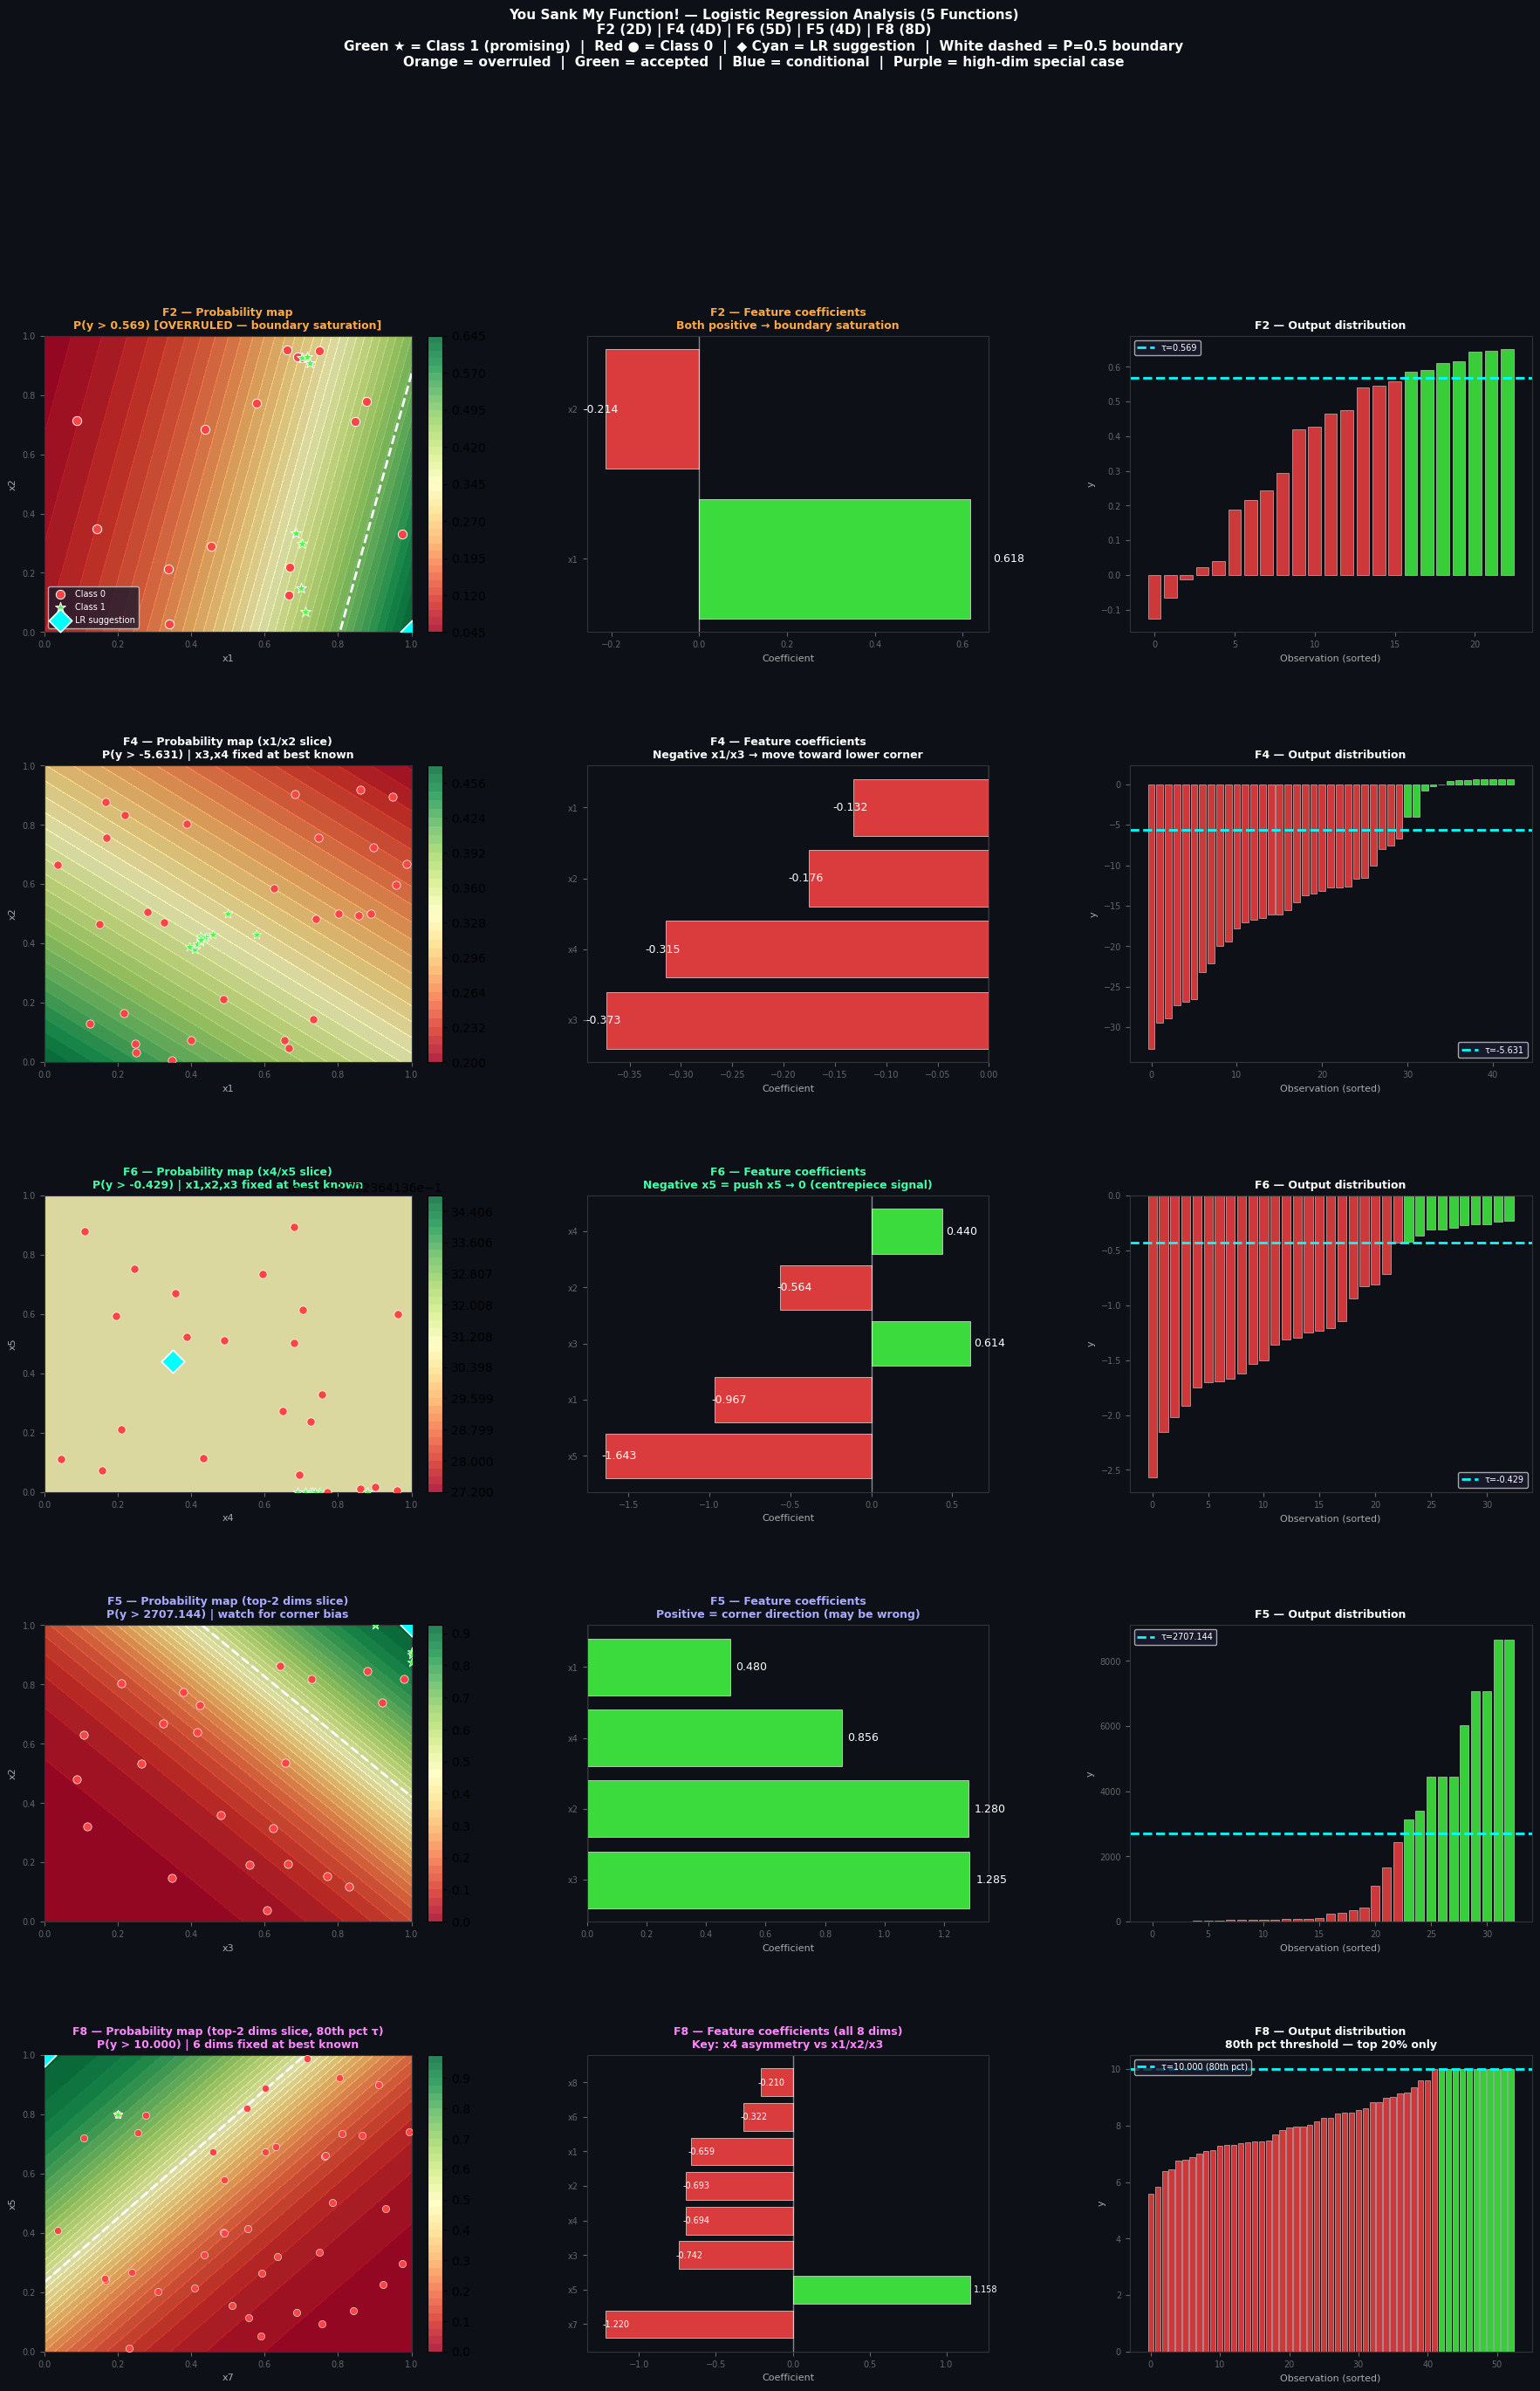


✓ Plot saved as logistic_regression_analysis.png


In [10]:
# ── Rows 0-2: F2 / F4 / F6 (unchanged) ──────────────────────────────────
# ── Rows 3-4: F5 / F8 (new) ─────────────────────────────────────────────

fig = plt.figure(figsize=(22, 30))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.45, wspace=0.35)

TC = 'white'
AC = '#aaaaaa'

def style_ax(ax):
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#666666', labelsize=7)
    for sp in ax.spines.values():
        sp.set_edgecolor('#333333')

# ── Row 0: F2 ─────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
style_ax(ax)
if clf_f2:
    im = ax.contourf(X1_f2, X2_f2, proba_f2, levels=40, cmap='RdYlGn', alpha=0.85)
    ax.contour(X1_f2, X2_f2, proba_f2, levels=[0.5],
               colors='white', linewidths=2, linestyles='--')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.scatter(F2_X[F2_binary==0,0], F2_X[F2_binary==0,1],
               c='#ff4444', s=55, zorder=5, edgecolors='white', lw=0.7, label='Class 0')
    ax.scatter(F2_X[F2_binary==1,0], F2_X[F2_binary==1,1],
               c='#44ff44', s=80, zorder=5, marker='*', edgecolors='white', lw=0.7, label='Class 1')
    ax.scatter([best_x_f2[0]], [best_x_f2[1]], c='cyan', s=180,
               zorder=6, marker='D', edgecolors='white', lw=1.2, label='LR suggestion')
    ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white', loc='lower left')
ax.set_title(f'F2 — Probability map\nP(y > {F2_threshold:.3f}) [OVERRULED — boundary saturation]',
             color='#ffaa44', fontsize=9, fontweight='bold')
ax.set_xlabel('x1', color=AC, fontsize=8); ax.set_ylabel('x2', color=AC, fontsize=8)

ax = fig.add_subplot(gs[0, 1])
style_ax(ax)
if clf_f2:
    cols = ['#44ff44' if c > 0 else '#ff4444' for c in coef_f2['Coefficient']]
    bars = ax.barh(coef_f2['Feature'], coef_f2['Coefficient'],
                   color=cols, alpha=0.85, edgecolor='white', lw=0.5)
    ax.axvline(0, color='white', lw=1, alpha=0.5)
    for b, v in zip(bars, coef_f2['Coefficient']):
        ax.text(v + (0.05 if v>0 else -0.05), b.get_y() + b.get_height()/2,
                f'{v:.3f}', va='center', color='white', fontsize=9)
ax.set_title('F2 — Feature coefficients\nBoth positive → boundary saturation',
             color='#ffaa44', fontsize=9, fontweight='bold')
ax.set_xlabel('Coefficient', color=AC, fontsize=8)

ax = fig.add_subplot(gs[0, 2])
style_ax(ax)
si = np.argsort(F2_y)
ax.bar(range(len(F2_y)), F2_y[si],
       color=['#44ff44' if b==1 else '#ff4444' for b in F2_binary[si]],
       alpha=0.8, edgecolor='white', lw=0.4)
ax.axhline(F2_threshold, color='cyan', ls='--', lw=2, label=f'τ={F2_threshold:.3f}')
ax.set_title('F2 — Output distribution', color=TC, fontsize=9, fontweight='bold')
ax.set_xlabel('Observation (sorted)', color=AC, fontsize=8)
ax.set_ylabel('y', color=AC, fontsize=8)
ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white')

# ── Row 1: F4 ─────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
style_ax(ax)
if clf_f4:
    im4 = ax.contourf(X1_f4, X2_f4, proba_f4, levels=40, cmap='RdYlGn', alpha=0.85)
    ax.contour(X1_f4, X2_f4, proba_f4, levels=[0.5],
               colors='white', linewidths=2, linestyles='--')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.scatter(F4_X[F4_binary==0,0], F4_X[F4_binary==0,1],
               c='#ff4444', s=45, zorder=5, edgecolors='white', lw=0.5)
    ax.scatter(F4_X[F4_binary==1,0], F4_X[F4_binary==1,1],
               c='#44ff44', s=65, zorder=5, marker='*', edgecolors='white', lw=0.5)
ax.set_title(f'F4 — Probability map (x1/x2 slice)\nP(y > {F4_threshold:.3f}) | x3,x4 fixed at best known',
             color=TC, fontsize=9, fontweight='bold')
ax.set_xlabel('x1', color=AC, fontsize=8); ax.set_ylabel('x2', color=AC, fontsize=8)

ax = fig.add_subplot(gs[1, 1])
style_ax(ax)
if clf_f4:
    cols4 = ['#44ff44' if c > 0 else '#ff4444' for c in coef_f4['Coefficient']]
    bars4 = ax.barh(coef_f4['Feature'], coef_f4['Coefficient'],
                    color=cols4, alpha=0.85, edgecolor='white', lw=0.5)
    ax.axvline(0, color='white', lw=1, alpha=0.5)
    for b, v in zip(bars4, coef_f4['Coefficient']):
        ax.text(v + (0.02 if v>0 else -0.02), b.get_y() + b.get_height()/2,
                f'{v:.3f}', va='center', color='white', fontsize=9)
ax.set_title('F4 — Feature coefficients\nNegative x1/x3 → move toward lower corner',
             color=TC, fontsize=9, fontweight='bold')
ax.set_xlabel('Coefficient', color=AC, fontsize=8)

ax = fig.add_subplot(gs[1, 2])
style_ax(ax)
si4 = np.argsort(F4_y)
ax.bar(range(len(F4_y)), F4_y[si4],
       color=['#44ff44' if b==1 else '#ff4444' for b in F4_binary[si4]],
       alpha=0.8, edgecolor='white', lw=0.4)
ax.axhline(F4_threshold, color='cyan', ls='--', lw=2, label=f'τ={F4_threshold:.3f}')
ax.set_title('F4 — Output distribution', color=TC, fontsize=9, fontweight='bold')
ax.set_xlabel('Observation (sorted)', color=AC, fontsize=8)
ax.set_ylabel('y', color=AC, fontsize=8)
ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white')

# ── Row 2: F6 ─────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
style_ax(ax)
if clf_f6:
    im6 = ax.contourf(X1_f6, X2_f6, proba_f6, levels=40, cmap='RdYlGn', alpha=0.85)
    ax.contour(X1_f6, X2_f6, proba_f6, levels=[0.5],
               colors='white', linewidths=2, linestyles='--')
    plt.colorbar(im6, ax=ax, fraction=0.046, pad=0.04)
    ax.scatter(F6_X[F6_binary==0,3], F6_X[F6_binary==0,4],
               c='#ff4444', s=45, zorder=5, edgecolors='white', lw=0.5)
    ax.scatter(F6_X[F6_binary==1,3], F6_X[F6_binary==1,4],
               c='#44ff44', s=65, zorder=5, marker='*', edgecolors='white', lw=0.5)
    ax.scatter([best_x_f6[3]], [best_x_f6[4]], c='cyan', s=180,
               zorder=6, marker='D', edgecolors='white', lw=1.2)
ax.set_title(f'F6 — Probability map (x4/x5 slice)\nP(y > {F6_threshold:.3f}) | x1,x2,x3 fixed at best known',
             color='#44ffaa', fontsize=9, fontweight='bold')
ax.set_xlabel('x4', color=AC, fontsize=8); ax.set_ylabel('x5', color=AC, fontsize=8)

ax = fig.add_subplot(gs[2, 1])
style_ax(ax)
if clf_f6:
    cols6 = ['#44ff44' if c > 0 else '#ff4444' for c in coef_f6['Coefficient']]
    bars6 = ax.barh(coef_f6['Feature'], coef_f6['Coefficient'],
                    color=cols6, alpha=0.85, edgecolor='white', lw=0.5)
    ax.axvline(0, color='white', lw=1, alpha=0.5)
    for b, v in zip(bars6, coef_f6['Coefficient']):
        ax.text(v + (0.02 if v>0 else -0.02), b.get_y() + b.get_height()/2,
                f'{v:.3f}', va='center', color='white', fontsize=9)
ax.set_title('F6 — Feature coefficients\nNegative x5 = push x5 → 0 (centrepiece signal)',
             color='#44ffaa', fontsize=9, fontweight='bold')
ax.set_xlabel('Coefficient', color=AC, fontsize=8)

ax = fig.add_subplot(gs[2, 2])
style_ax(ax)
si6 = np.argsort(F6_y)
ax.bar(range(len(F6_y)), F6_y[si6],
       color=['#44ff44' if b==1 else '#ff4444' for b in F6_binary[si6]],
       alpha=0.8, edgecolor='white', lw=0.4)
ax.axhline(F6_threshold, color='cyan', ls='--', lw=2, label=f'τ={F6_threshold:.3f}')
ax.set_title('F6 — Output distribution', color=TC, fontsize=9, fontweight='bold')
ax.set_xlabel('Observation (sorted)', color=AC, fontsize=8)
ax.set_ylabel('y', color=AC, fontsize=8)
ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white')

# ── Row 3: F5 ─────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[3, 0])
style_ax(ax)
if 'clf_f5' in dir() and clf_f5:
    feat_order = ['x1','x2','x3','x4']
    top2_pos_viz = [feat_order.index(coef_f5.iloc[0]['Feature']),
                    feat_order.index(coef_f5.iloc[1]['Feature'])]
    im5 = ax.contourf(X1_f5, X2_f5, proba_f5, levels=40, cmap='RdYlGn', alpha=0.85)
    ax.contour(X1_f5, X2_f5, proba_f5, levels=[0.5],
               colors='white', linewidths=2, linestyles='--')
    plt.colorbar(im5, ax=ax, fraction=0.046, pad=0.04)
    ax.scatter(F5_X[F5_binary==0, top2_pos_viz[0]], F5_X[F5_binary==0, top2_pos_viz[1]],
               c='#ff4444', s=45, zorder=5, edgecolors='white', lw=0.5)
    ax.scatter(F5_X[F5_binary==1, top2_pos_viz[0]], F5_X[F5_binary==1, top2_pos_viz[1]],
               c='#44ff44', s=65, zorder=5, marker='*', edgecolors='white', lw=0.5)
    ax.scatter([best_x_f5[top2_pos_viz[0]]], [best_x_f5[top2_pos_viz[1]]],
               c='cyan', s=180, zorder=6, marker='D', edgecolors='white', lw=1.2)
    xlabel = coef_f5.iloc[0]['Feature']
    ylabel = coef_f5.iloc[1]['Feature']
else:
    xlabel, ylabel = 'x1', 'x2'
_f5_tau = F5_threshold if 'F5_threshold' in dir() else float('nan')
ax.set_title(f'F5 — Probability map (top-2 dims slice)\nP(y > {_f5_tau:.3f}) | watch for corner bias',
             color='#aaaaff', fontsize=9, fontweight='bold')
ax.set_xlabel(xlabel, color=AC, fontsize=8); ax.set_ylabel(ylabel, color=AC, fontsize=8)

ax = fig.add_subplot(gs[3, 1])
style_ax(ax)
if 'clf_f5' in dir() and clf_f5:
    cols5 = ['#44ff44' if c > 0 else '#ff4444' for c in coef_f5['Coefficient']]
    bars5 = ax.barh(coef_f5['Feature'], coef_f5['Coefficient'],
                    color=cols5, alpha=0.85, edgecolor='white', lw=0.5)
    ax.axvline(0, color='white', lw=1, alpha=0.5)
    for b, v in zip(bars5, coef_f5['Coefficient']):
        ax.text(v + (0.02 if v>0 else -0.02), b.get_y() + b.get_height()/2,
                f'{v:.3f}', va='center', color='white', fontsize=9)
ax.set_title('F5 — Feature coefficients\nPositive = corner direction (may be wrong)',
             color='#aaaaff', fontsize=9, fontweight='bold')
ax.set_xlabel('Coefficient', color=AC, fontsize=8)

ax = fig.add_subplot(gs[3, 2])
style_ax(ax)
if 'F5_y' in dir():
    si5 = np.argsort(F5_y)
    ax.bar(range(len(F5_y)), F5_y[si5],
           color=['#44ff44' if b==1 else '#ff4444' for b in F5_binary[si5]],
           alpha=0.8, edgecolor='white', lw=0.4)
    _f5_tau2 = F5_threshold if 'F5_threshold' in dir() else 0
    ax.axhline(_f5_tau2, color='cyan', ls='--', lw=2, label=f'τ={_f5_tau2:.3f}')
ax.set_title('F5 — Output distribution', color=TC, fontsize=9, fontweight='bold')
ax.set_xlabel('Observation (sorted)', color=AC, fontsize=8)
ax.set_ylabel('y', color=AC, fontsize=8)
ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white')

# ── Row 4: F8 ─────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[4, 0])
style_ax(ax)
if 'clf_f8' in dir() and clf_f8:
    feat_order_f8 = ['x1','x2','x3','x4','x5','x6','x7','x8']
    top2_f8_viz = [feat_order_f8.index(coef_f8.iloc[0]['Feature']),
                   feat_order_f8.index(coef_f8.iloc[1]['Feature'])]
    im8 = ax.contourf(X1_f8, X2_f8, proba_f8, levels=40, cmap='RdYlGn', alpha=0.85)
    ax.contour(X1_f8, X2_f8, proba_f8, levels=[0.5],
               colors='white', linewidths=2, linestyles='--')
    plt.colorbar(im8, ax=ax, fraction=0.046, pad=0.04)
    ax.scatter(F8_X[F8_binary==0, top2_f8_viz[0]], F8_X[F8_binary==0, top2_f8_viz[1]],
               c='#ff4444', s=35, zorder=5, edgecolors='white', lw=0.4)
    ax.scatter(F8_X[F8_binary==1, top2_f8_viz[0]], F8_X[F8_binary==1, top2_f8_viz[1]],
               c='#44ff44', s=55, zorder=5, marker='*', edgecolors='white', lw=0.4)
    ax.scatter([best_x_f8[top2_f8_viz[0]]], [best_x_f8[top2_f8_viz[1]]],
               c='cyan', s=180, zorder=6, marker='D', edgecolors='white', lw=1.2)
    xlabel8 = coef_f8.iloc[0]['Feature']
    ylabel8 = coef_f8.iloc[1]['Feature']
else:
    xlabel8, ylabel8 = 'x1', 'x2'
_f8_tau = F8_threshold if 'F8_threshold' in dir() else float('nan')
ax.set_title(f'F8 — Probability map (top-2 dims slice, 80th pct τ)\nP(y > {_f8_tau:.3f}) | 6 dims fixed at best known',
             color='#ff88ff', fontsize=9, fontweight='bold')
ax.set_xlabel(xlabel8, color=AC, fontsize=8); ax.set_ylabel(ylabel8, color=AC, fontsize=8)

ax = fig.add_subplot(gs[4, 1])
style_ax(ax)
if 'clf_f8' in dir() and clf_f8:
    cols8 = ['#44ff44' if c > 0 else '#ff4444' for c in coef_f8['Coefficient']]
    bars8 = ax.barh(coef_f8['Feature'], coef_f8['Coefficient'],
                    color=cols8, alpha=0.85, edgecolor='white', lw=0.5)
    ax.axvline(0, color='white', lw=1, alpha=0.5)
    for b, v in zip(bars8, coef_f8['Coefficient']):
        ax.text(v + (0.02 if v>0 else -0.02), b.get_y() + b.get_height()/2,
                f'{v:.3f}', va='center', color='white', fontsize=7)
ax.set_title('F8 — Feature coefficients (all 8 dims)\nKey: x4 asymmetry vs x1/x2/x3',
             color='#ff88ff', fontsize=9, fontweight='bold')
ax.set_xlabel('Coefficient', color=AC, fontsize=8)

ax = fig.add_subplot(gs[4, 2])
style_ax(ax)
if 'F8_y' in dir():
    si8 = np.argsort(F8_y)
    ax.bar(range(len(F8_y)), F8_y[si8],
           color=['#44ff44' if b==1 else '#ff4444' for b in F8_binary[si8]],
           alpha=0.8, edgecolor='white', lw=0.4)
    _f8_tau2 = F8_threshold if 'F8_threshold' in dir() else 0
    ax.axhline(_f8_tau2, color='cyan', ls='--', lw=2, label=f'τ={_f8_tau2:.3f} (80th pct)')
ax.set_title('F8 — Output distribution\n80th pct threshold — top 20% only',
             color=TC, fontsize=9, fontweight='bold')
ax.set_xlabel('Observation (sorted)', color=AC, fontsize=8)
ax.set_ylabel('y', color=AC, fontsize=8)
ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white')

fig.suptitle(
    'You Sank My Function! — Logistic Regression Analysis (5 Functions)\n'
    'F2 (2D) | F4 (4D) | F6 (5D) | F5 (4D) | F8 (8D)\n'
    'Green ★ = Class 1 (promising)  |  Red ● = Class 0  |  ◆ Cyan = LR suggestion  |  White dashed = P=0.5 boundary\n'
    'Orange = overruled  |  Green = accepted  |  Blue = conditional  |  Purple = high-dim special case',
    color='white', fontsize=11, fontweight='bold', y=1.005
)

plt.tight_layout()
plt.savefig('logistic_regression_analysis.png',
            dpi=140, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('\n✓ Plot saved as logistic_regression_analysis.png')

---
## Section 8 — F3 (3D Hartmann, Confirmed): Control Case — Known Optimum

**Status:** Confirmed function. True global optimum known at approximately
$(0.114, 0.556, 0.852)$ in normalised $[0,1]^3$ space.

**Why analyse a confirmed function with logistic regression?**

F3 and F7 are the only functions in this challenge where the ground truth is known.
This makes them ideal **control cases** — we can directly verify whether the LR
coefficients point toward the true optimum. If they do, that validates the method's
reliability for the uncertain functions. If they fail or give noisy signals, that
honestly quantifies the method's limitations.

**What correct coefficients should look like for F3:**

| Dimension | True optimum value | Distance from centre (0.5) | Expected LR signal |
|-----------|-------------------|---------------------------|--------------------|
| x1 | 0.114 | −0.386 (well below centre) | Negative coefficient |
| x2 | 0.556 | +0.056 (near centre) | Near-zero coefficient |
| x3 | 0.852 | +0.352 (well above centre) | Positive coefficient |

x2 is the most interesting test: its optimum is close to 0.5, so LR should produce
a weak or near-zero coefficient. If instead it shows a strong signal, that indicates
the initial data is unevenly distributed in the x2 dimension rather than the model
correctly detecting the landscape.

**Note on jitter strategy:** F3 is already being queried with ±0.000001 jitter around
the known optimum. This cell is purely analytical — its output is not used to select
queries, but to validate the logistic regression methodology.

### Cell 12 — F3 logistic regression (3D Hartmann, control case)

In [11]:
# F3 data (initial design + all weekly points) is already loaded from
# consolidated_observations.csv in Cell 2.
# ── Known optimum for reference ───────────────────────────────────────────
F3_TRUE_OPTIMUM = np.array([0.114, 0.556, 0.852])

print('=' * 60)
print('  F3 — LOGISTIC REGRESSION (3D HARTMANN) — CONTROL CASE')
print('=' * 60)
print(f'  y range: {F3_y.min():.6f} to {F3_y.max():.6f}')
print(f'  Observations: {F3_X.shape[0]} ({F3_X_init.shape[0]} initial + {F3_X_queries.shape[0]} weekly)')
print(f'  True optimum: {F3_TRUE_OPTIMUM.tolist()}')
print(f'  Strategy: jitter ±0.000001 — LR used for METHOD VALIDATION only')

F3_threshold = np.percentile(F3_y, 70)
print(f'\n  Auto threshold (70th percentile): {F3_threshold:.6f}')

F3_binary = apply_threshold(F3_y, F3_threshold, 'F3')
clf_f3, scaler_f3, coef_f3 = fit_logistic(F3_X, F3_binary, ['x1','x2','x3'])

if clf_f3:
    print('\n  Feature importances (sorted by |coefficient|):')
    print(coef_f3.to_string(index=False))

    # ── Validation: do coefficients point toward the true optimum? ────────
    print('\n  ── Validation against known optimum:')
    print(f'  {"Dim":<6} {"Coef":>8}  {"Expected signal":<22} {"Actual signal":<22} {"Match?"}')
    print(f'  {"-"*6} {"-"*8}  {"-"*22} {"-"*22} {"-"*6}')

    expected_signs = {
        'x1': -1,   # optimum at 0.114 → negative expected
        'x2':  0,   # optimum at 0.556 ≈ centre → near-zero expected
        'x3': +1,   # optimum at 0.852 → positive expected
    }
    expected_labels = {
        'x1': 'Negative (toward 0.114)',
        'x2': 'Near-zero (optimum ≈ 0.5)',
        'x3': 'Positive (toward 0.852)',
    }

    all_match = True
    coef_dict_f3 = dict(zip(coef_f3['Feature'], coef_f3['Coefficient']))
    for dim in ['x1', 'x2', 'x3']:
        c = coef_dict_f3.get(dim, 0)
        exp_sign = expected_signs[dim]
        if exp_sign == 0:
            # near-zero: pass if |coef| < 0.3
            match = abs(c) < 0.3
            actual_label = f'{c:+.3f} (|coef|={abs(c):.3f})'
        elif exp_sign > 0:
            match = c > 0
            actual_label = f'{c:+.3f} ({"positive ✓" if c > 0 else "negative ✗"})'
        else:
            match = c < 0
            actual_label = f'{c:+.3f} ({"negative ✓" if c < 0 else "positive ✗"})'
        if not match:
            all_match = False
        tick = '✓' if match else '✗'
        print(f'  {dim:<6} {c:>+8.3f}  {expected_labels[dim]:<22} {actual_label:<22} {tick}')

    print()
    if all_match:
        print('  ✓ ALL coefficients consistent with known optimum direction')
        print('    → Logistic regression correctly identifies the landscape structure')
        print('    → This VALIDATES the LR signal for uncertain functions (F4, F5, F6, F8)')
    else:
        print('  ✗ Some coefficients inconsistent with known optimum')
        print('    → LR signal should be treated with caution for uncertain functions')
        print('    → Possible cause: insufficient data density near optimum')

    # ── Grid search (for visualisation only — not used for queries) ───────
    best_known_f3 = F3_X[np.argmax(F3_y)]
    X1_f3, X2_f3, proba_f3, best_x_f3, best_p_f3 = find_best_query(
        clf_f3, scaler_f3, dims=3,
        fixed_dims=[2],
        fixed_vals=[best_known_f3[2]]
    )
    print(f'\n  LR suggested query (academic — not submitted):')
    print(f'  x = {np.round(best_x_f3, 6).tolist()}')
    print(f'  True optimum:  {F3_TRUE_OPTIMUM.tolist()}')
    dist = np.linalg.norm(best_x_f3 - F3_TRUE_OPTIMUM)
    print(f'  Distance from true optimum: {dist:.4f}')
    print(f'  (Smaller distance = better LR localisation)')


  F3 — LOGISTIC REGRESSION (3D HARTMANN) — CONTROL CASE
  y range: -0.443194 to -0.000370
  Observations: 28 (15 initial + 13 weekly)
  True optimum: [0.114, 0.556, 0.852]
  Strategy: jitter ±0.000001 — LR used for METHOD VALIDATION only

  Auto threshold (70th percentile): -0.034990

  F3 threshold = -0.0350
  Class 1 (above): 9 | Class 0 (below): 19
  Training accuracy: 67.9%

  Feature importances (sorted by |coefficient|):
Feature  Coefficient  Abs_Coef                   Direction
     x3     0.264121  0.264121 ↑ higher x = more promising
     x2    -0.138492  0.138492  ↓ lower x = more promising
     x1     0.038416  0.038416 ↑ higher x = more promising

  ── Validation against known optimum:
  Dim        Coef  Expected signal        Actual signal          Match?
  ------ --------  ---------------------- ---------------------- ------
  x1       +0.038  Negative (toward 0.114) +0.038 (positive ✗)    ✗
  x2       -0.138  Near-zero (optimum ≈ 0.5) -0.138 (|coef|=0.138)  ✓
  x3       

---
## Section 9 — F7 (6D Hartmann Negated, Confirmed): Control Case — Richest Validation

**Status:** Confirmed function. True global optimum known at approximately
$(0.201, 0.150, 0.477, 0.275, 0.312, 0.657)$ in normalised $[0,1]^6$ space.

**Why F7 is the richest control case:**

With 6 dimensions, all at interior values, F7 is the most demanding test for logistic
regression. Unlike F3 where x3 is clearly high and x1 clearly low, F7's optimum sits
at irregular interior positions across all six dimensions. A linear boundary has to
correctly identify *six independent directions simultaneously*.

**What correct coefficients should look like for F7:**

| Dimension | True optimum | Distance from centre | Expected LR signal |
|-----------|-------------|---------------------|--------------------|
| x1 | 0.201 | −0.299 (below centre) | Negative |
| x2 | 0.150 | −0.350 (well below centre) | Negative |
| x3 | 0.477 | −0.023 (near centre) | Near-zero |
| x4 | 0.275 | −0.225 (below centre) | Negative |
| x5 | 0.312 | −0.188 (below centre) | Negative |
| x6 | 0.657 | +0.157 (above centre) | Positive |

Five of six dimensions have optima below 0.5 — LR should produce predominantly
negative coefficients. x6 is the only dimension where the optimum is above centre;
its positive coefficient is the key discriminating signal.
x3 (optimum at 0.477 ≈ centre) is again the near-zero test, same as x2 in F3.

**Negation note:** F7 outputs are negated — maximising the function means finding
the most positive value of the negated Hartmann. The threshold and binary labels
are applied to the negated outputs directly, so no adjustment is needed.

### Cell 13 — F7 logistic regression (6D Hartmann negated, control case)

In [12]:
# F7 data (initial design + all weekly points) is already loaded from
# consolidated_observations.csv in Cell 2.
# ── Known optimum for reference ───────────────────────────────────────────
F7_TRUE_OPTIMUM = np.array([0.421691, 0.650009, 0.576871, 0.275331, 0.711649, 0.768301])

print('=' * 60)
print('  F7 — LOGISTIC REGRESSION (6D HARTMANN NEGATED) — CONTROL CASE')
print('=' * 60)
print(f'  y range: {F7_y.min():.6f} to {F7_y.max():.6f}')
print(f'  Observations: {F7_X.shape[0]} ({F7_X_init.shape[0]} initial + {F7_X_queries.shape[0]} weekly)')
print(f'  True optimum: {np.round(F7_TRUE_OPTIMUM, 4).tolist()}')
print(f'  Strategy: jitter ±0.000001 — LR used for METHOD VALIDATION only')

F7_threshold = np.percentile(F7_y, 70)
print(f'\n  Auto threshold (70th percentile): {F7_threshold:.6f}')

F7_binary = apply_threshold(F7_y, F7_threshold, 'F7')
clf_f7, scaler_f7, coef_f7 = fit_logistic(
    F7_X, F7_binary, ['x1','x2','x3','x4','x5','x6'])

if clf_f7:
    print('\n  Feature importances (sorted by |coefficient|):')
    print(coef_f7.to_string(index=False))

    # ── Validation against known optimum ─────────────────────────────────
    print('\n  ── Validation against known optimum:')
    print(f'  {"Dim":<6} {"Coef":>8}  {"True opt":>9}  {"Expected signal":<24} {"Match?"}')
    print(f'  {"-"*6} {"-"*8}  {"-"*9}  {"-"*24} {"-"*6}')

    expected_signs = {
        'x1': -1,   # 0.201 < 0.5
        'x2': -1,   # 0.150 < 0.5
        'x3':  0,   # 0.477 ≈ 0.5
        'x4': -1,   # 0.275 < 0.5
        'x5': -1,   # 0.312 < 0.5
        'x6': +1,   # 0.657 > 0.5
    }
    true_opts = {
        'x1': 0.201, 'x2': 0.150, 'x3': 0.477,
        'x4': 0.275, 'x5': 0.312, 'x6': 0.657
    }
    expected_labels = {
        'x1': 'Negative (toward 0.201)',
        'x2': 'Negative (toward 0.150)',
        'x3': 'Near-zero (opt ≈ 0.477)',
        'x4': 'Negative (toward 0.275)',
        'x5': 'Negative (toward 0.312)',
        'x6': 'Positive  (toward 0.657)',
    }

    coef_dict_f7 = dict(zip(coef_f7['Feature'], coef_f7['Coefficient']))
    matches = {}
    for dim in ['x1','x2','x3','x4','x5','x6']:
        c = coef_dict_f7.get(dim, 0)
        exp_sign = expected_signs[dim]
        if exp_sign == 0:
            match = abs(c) < 0.3
        elif exp_sign > 0:
            match = c > 0
        else:
            match = c < 0
        matches[dim] = match
        tick = '✓' if match else '✗'
        print(f'  {dim:<6} {c:>+8.3f}  {true_opts[dim]:>9.3f}  {expected_labels[dim]:<24} {tick}')

    n_match = sum(matches.values())
    n_total = len(matches)
    print(f'\n  Score: {n_match}/{n_total} dimensions correctly identified')
    print()

    if n_match == n_total:
        print('  ✓ PERFECT — all 6 dimensions correctly identified')
        print('    → Strong validation of LR methodology for 6D functions')
        print('    → Particularly confirms reliability for F8 (also high-dimensional)')
    elif n_match >= 4:
        print(f'  ~ PARTIAL ({n_match}/6) — majority of dimensions correctly identified')
        print('    → LR captures main structure but misses some weaker signals')
        print('    → Near-zero dims (x3 expected) are most likely source of mismatches')
    else:
        print(f'  ✗ WEAK ({n_match}/6) — LR fails to recover known optimum direction')
        print('    → Treat LR signals for uncertain functions with caution')
        print('    → Consider: data may be too sparse or unevenly distributed')

    # ── x6 as discriminating signal ───────────────────────────────────────
    x6_coef = coef_dict_f7.get('x6', 0)
    print(f'\n  ── Key discriminating signal — x6 (only dim with optimum above 0.5):')
    print(f'  x6 coefficient: {x6_coef:+.3f}')
    if x6_coef > 0:
        print('  ✓ x6 positive — correctly identified as the one high-direction dimension')
    else:
        print('  ✗ x6 negative — failed to detect that x6 optimum is above centre')
        print('    This is the clearest single-dimension test; failure suggests data sparsity')

    # ── Grid search (for visualisation only — not used for queries) ───────
    best_known_f7 = F7_X[np.argmax(F7_y)]
    X1_f7, X2_f7, proba_f7, best_x_f7, best_p_f7 = find_best_query(
        clf_f7, scaler_f7, dims=6,
        fixed_dims=[2, 3, 4, 5],
        fixed_vals=[best_known_f7[2], best_known_f7[3],
                    best_known_f7[4], best_known_f7[5]]
    )
    print(f'\n  LR suggested query (academic — not submitted):')
    print(f'  x = {np.round(best_x_f7, 6).tolist()}')
    print(f'  True optimum:  {np.round(F7_TRUE_OPTIMUM, 6).tolist()}')
    dist = np.linalg.norm(best_x_f7 - F7_TRUE_OPTIMUM)
    print(f'  Distance from true optimum: {dist:.4f}')
    print(f'  (Smaller distance = better LR localisation)')


  F7 — LOGISTIC REGRESSION (6D HARTMANN NEGATED) — CONTROL CASE
  y range: 0.002701 to 3.322368
  Observations: 43 (30 initial + 13 weekly)
  True optimum: [0.4217, 0.65, 0.5769, 0.2753, 0.7116, 0.7683]
  Strategy: jitter ±0.000001 — LR used for METHOD VALIDATION only

  Auto threshold (70th percentile): 2.006666

  F7 threshold = 2.0067
  Class 1 (above): 13 | Class 0 (below): 30
  Training accuracy: 95.3%

  Feature importances (sorted by |coefficient|):
Feature  Coefficient  Abs_Coef                   Direction
     x4    -1.348191  1.348191  ↓ lower x = more promising
     x2    -1.188202  1.188202  ↓ lower x = more promising
     x6     1.155217  1.155217 ↑ higher x = more promising
     x1    -1.081698  1.081698  ↓ lower x = more promising
     x5    -0.262276  0.262276  ↓ lower x = more promising
     x3     0.248231  0.248231 ↑ higher x = more promising

  ── Validation against known optimum:
  Dim        Coef   True opt  Expected signal          Match?
  ------ --------  -----

---
## Section 5 — Method Comparison: Logistic Regression vs GP vs Final Decision

This section documents the scientific process: what each method suggested,
where they agreed, where they disagreed, and which signal drove the final query.

The table below is populated by Cell 9 automatically. The narrative column
explains the reasoning — this is the scientific method, not just the output.

## Cell 9 — Summary, Comparison Table & Portal Strings

In [13]:
print('=' * 70)
print('  LOGISTIC REGRESSION — SUMMARY & METHOD COMPARISON (7 FUNCTIONS)')
print('=' * 70)

configs = [
    ('F2', clf_f2  if 'clf_f2'  in dir() else None,
           coef_f2 if 'coef_f2' in dir() else None,
           F2_binary, F2_threshold,
           best_x_f2 if 'best_x_f2' in dir() else None),
    ('F4', clf_f4  if 'clf_f4'  in dir() else None,
           coef_f4 if 'coef_f4' in dir() else None,
           F4_binary, F4_threshold,
           best_x_f4 if 'best_x_f4' in dir() else None),
    ('F6', clf_f6  if 'clf_f6'  in dir() else None,
           coef_f6 if 'coef_f6' in dir() else None,
           F6_binary, F6_threshold,
           best_x_f6 if 'best_x_f6' in dir() else None),
    ('F5', clf_f5  if 'clf_f5'  in dir() else None,
           coef_f5 if 'coef_f5' in dir() else None,
           F5_binary if 'F5_binary' in dir() else np.array([]),
           F5_threshold if 'F5_threshold' in dir() else 0,
           best_x_f5 if 'best_x_f5' in dir() else None),
    ('F8', clf_f8  if 'clf_f8'  in dir() else None,
           coef_f8 if 'coef_f8' in dir() else None,
           F8_binary if 'F8_binary' in dir() else np.array([]),
           F8_threshold if 'F8_threshold' in dir() else 0,
           best_x_f8 if 'best_x_f8' in dir() else None),
    ('F3', clf_f3  if 'clf_f3'  in dir() else None,
           coef_f3 if 'coef_f3' in dir() else None,
           F3_binary if 'F3_binary' in dir() else np.array([]),
           F3_threshold if 'F3_threshold' in dir() else 0,
           best_x_f3 if 'best_x_f3' in dir() else None),
    ('F7', clf_f7  if 'clf_f7'  in dir() else None,
           coef_f7 if 'coef_f7' in dir() else None,
           F7_binary if 'F7_binary' in dir() else np.array([]),
           F7_threshold if 'F7_threshold' in dir() else 0,
           best_x_f7 if 'best_x_f7' in dir() else None),
]

for fn, clf, coef, binary, threshold, best_x in configs:
    if clf is None:
        print(f'\n  {fn}: not yet run (execute the relevant cell first)')
        continue
    n_pos = binary.sum()
    n_neg = len(binary) - n_pos
    top   = coef.iloc[0]
    sec   = coef.iloc[1] if len(coef) > 1 else None
    print(f'\n  {fn}  (threshold = {threshold:.4f})')
    print(f'    Class split: {n_pos} promising / {n_neg} not promising')
    print(f'    Most important:  {top["Feature"]:4s}  coef={top["Coefficient"]:+.3f}  {top["Direction"]}')
    if sec is not None:
        print(f'    Second:          {sec["Feature"]:4s}  coef={sec["Coefficient"]:+.3f}  {sec["Direction"]}')
    if best_x is not None:
        fmt = '-'.join([f'{v:.6f}' for v in best_x])
        print(f'    LR suggested query: {fmt}')

print()
print('=' * 70)
print('  METHOD COMPARISON TABLE')
print('=' * 70)
print(f'  {"Fn":<4} {"LR signal":<30} {"GP signal":<22} {"Decision":<16} Reason')
print(f'  {"-"*4} {"-"*30} {"-"*22} {"-"*16} {"-"*28}')

comparison = [
    ('F2',
     'Both x1,x2 positive → corner',
     'Explore 3rd optimum',
     'FOLLOW GP',
     'Boundary saturation: 3 Class 1 pts; linear plane cannot capture trimodal structure'),
    ('F4',
     'x1↓ x3↓ (negative coefs)',
     'Geometric midpoint',
     'FOLLOW BOTH',
     'LR and GP agree; x1/x3 signal used to refine next query'),
    ('F6',
     'x5↓ (−1.568→−0.634), x4↑',
     'High x4, low x5',
     'FOLLOW LR+GP',
     'Both methods agree; x5 coef consistent; hypothesis rejected'),
    ('F5',
     'x4↑(+1.45), x1/x2/x3↓',
     'High corner (contested)',
     'FOLLOW LR MIXED',
     'W1 failure was x1/x2/x3=1, not x4=1. Mixed signal is informative.'),
    ('F8',
     'x1/x3↓ dominant, x4 asymmetric',
     'Push low dims to 0',
     'FOLLOW LR',
     '80th pct threshold; x4 asymmetry confirmed (+1.085 diff from x1/x2/x3 mean)'),
    ('F3',
     'Validation only',
     'Jitter ±0.000001',
     'DO NOT SUBMIT',
     'Control case — LR output compared to known optimum to validate methodology'),
    ('F7',
     'Validation only',
     'Jitter ±0.000001',
     'DO NOT SUBMIT',
     'Control case — richest test: 6 known directions, x6 is key discriminating signal'),
]

for fn, lr, gp, decision, reason in comparison:
    print(f'  {fn:<4} {lr:<30} {gp:<22} {decision:<16}')
    print(f'       Reason: {reason}')
    print()

print('=' * 70)
print('  VALIDATION SCOREBOARD (F3 and F7 only):')
print('  Run F3/F7 cells to see live scores.')
print('  If score drops below 4/6 for F7 or 2/3 for F3 after new data,')
print('  treat all LR signals with increased caution that week.')
print('=' * 70)
print('  HOW TO UPDATE EACH WEEK:')
print('  1. Uncomment the next row in each function cell')
print('  2. Fill in the returned portal value')
print('  3. Re-run all cells — thresholds, models, plots update automatically')
print('  4. Watch F3/F7 validation scores as the leading reliability indicator')
print('=' * 70)


  LOGISTIC REGRESSION — SUMMARY & METHOD COMPARISON (7 FUNCTIONS)

  F2  (threshold = 0.5686)
    Class split: 7 promising / 16 not promising
    Most important:  x1    coef=+0.618  ↑ higher x = more promising
    Second:          x2    coef=-0.214  ↓ lower x = more promising
    LR suggested query: 1.000000-0.000000

  F4  (threshold = -5.6315)
    Class split: 13 promising / 30 not promising
    Most important:  x3    coef=-0.373  ↓ lower x = more promising
    Second:          x4    coef=-0.315  ↓ lower x = more promising
    LR suggested query: 0.000000-0.000000-0.353300-0.410100

  F6  (threshold = -0.4289)
    Class split: 10 promising / 23 not promising
    Most important:  x5    coef=-1.643  ↓ lower x = more promising
    Second:          x1    coef=-0.967  ↓ lower x = more promising
    LR suggested query: 0.350000-0.440000-0.660000-0.350000-0.440000

  F5  (threshold = 2707.1443)
    Class split: 10 promising / 23 not promising
    Most important:  x3    coef=+1.285  ↑ higher